In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
DATA_PATH = r"D:\projects\AI-Stock-Analytics-System\data\final\feature_engineered_stock_data.csv"

df = pd.read_csv(DATA_PATH)

In [3]:
df.shape

(418075, 49)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418075 entries, 0 to 418074
Data columns (total 49 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    418075 non-null  object 
 1   Close                   418075 non-null  float64
 2   High                    418075 non-null  float64
 3   Low                     418075 non-null  float64
 4   Open                    418075 non-null  float64
 5   Volume                  418075 non-null  float64
 6   Ticker                  418075 non-null  object 
 7   Daily_Return            418075 non-null  float64
 8   MA5                     418075 non-null  float64
 9   MA10                    418075 non-null  float64
 10  MA20                    418075 non-null  float64
 11  MA50                    418075 non-null  float64
 12  EMA20                   418075 non-null  float64
 13  RSI                     418075 non-null  float64
 14  EMA12               

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418075 entries, 0 to 418074
Data columns (total 49 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Date                    418075 non-null  datetime64[ns]
 1   Close                   418075 non-null  float64       
 2   High                    418075 non-null  float64       
 3   Low                     418075 non-null  float64       
 4   Open                    418075 non-null  float64       
 5   Volume                  418075 non-null  float64       
 6   Ticker                  418075 non-null  object        
 7   Daily_Return            418075 non-null  float64       
 8   MA5                     418075 non-null  float64       
 9   MA10                    418075 non-null  float64       
 10  MA20                    418075 non-null  float64       
 11  MA50                    418075 non-null  float64       
 12  EMA20                   418075

In [7]:
feature_columns = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "Daily_Return",
    "MA5",
    "MA10",
    "MA20",
    "MA50",
    "EMA20",
    "RSI",
    "EMA12",
    "EMA26",
    "MACD",
    "Signal_Line",
    "MACD_Histogram",
    "Upper_Band",
    "Lower_Band",
    "Volatility",
    "Lag1",
    "Lag2",
    "Lag3"
]

In [8]:
X_reg = df[feature_columns]
y_reg = df["Target_Close"]

In [9]:
X_clf = df[feature_columns]
y_clf = df["Target_Signal"]

In [10]:
df = df.sort_values(
    ["Date", "Ticker"]
).reset_index(drop=True)

In [11]:
print("Start Date :", df["Date"].min())
print("End Date   :", df["Date"].max())

Start Date : 2008-03-04 00:00:00
End Date   : 2026-07-23 00:00:00


In [12]:
split_date = "2024-01-01"

In [13]:
X_train_reg = X_reg[
    df["Date"] < split_date]
X_test_reg = X_reg[
    df["Date"] >= split_date]
y_train_reg = y_reg[
    df["Date"] < split_date]
y_test_reg = y_reg[
    df["Date"] >= split_date]

In [14]:
X_train_clf = X_clf[
    df["Date"] < split_date]
X_test_clf = X_clf[
    df["Date"] >= split_date]
y_train_clf = y_clf[
    df["Date"] < split_date]
y_test_clf = y_clf[
    df["Date"] >= split_date]

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [16]:
X_train_reg_scaled = scaler.fit_transform(X_train_reg)

In [17]:
X_test_reg_scaled = scaler.transform(X_test_reg)

In [18]:
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [20]:
baseline_pred = X_test_reg["Close"]

In [21]:
import numpy as np
baseline_mae = mean_absolute_error(
    y_test_reg,
    baseline_pred)
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        baseline_pred))
baseline_r2 = r2_score(
    y_test_reg,
    baseline_pred)
print(f"Baseline MAE : {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²  : {baseline_r2:.4f}")

Baseline MAE : 9.66
Baseline RMSE: 26.34
Baseline R²  : 0.9997


In [22]:
regression_results = pd.DataFrame(
    columns=["Model", "MAE", "RMSE", "R2"])
regression_results.loc[len(regression_results)] = [
    "Baseline",
    baseline_mae,
    baseline_rmse,
    baseline_r2]
regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.66202,26.33786,0.999705


In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
lr = LinearRegression()
lr.fit(
    X_train_reg_scaled,
    y_train_reg
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
lr_pred = lr.predict(
    X_test_reg_scaled
)

In [26]:
lr_mae = mean_absolute_error(
    y_test_reg,
    lr_pred)
lr_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        lr_pred))
lr_r2 = r2_score(
    y_test_reg,
    lr_pred)
print(f"Linear Regression MAE  : {lr_mae:.2f}")
print(f"Linear Regression RMSE : {lr_rmse:.2f}")
print(f"Linear Regression R²   : {lr_r2:.4f}")

Linear Regression MAE  : 9.69
Linear Regression RMSE : 26.33
Linear Regression R²   : 0.9997


In [27]:
regression_results.loc[len(regression_results)] = [
    "Linear Regression",
    lr_mae,
    lr_rmse,
    lr_r2
]

regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.662020,26.337860,0.999705
1,Linear Regression,9.691324,26.333005,0.999705


In [28]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [29]:
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]}

In [30]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

In [31]:
ridge_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [32]:
ridge_search.fit(
    X_train_reg_scaled,
    y_train_reg
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [33]:
print("Best Alpha:", ridge_search.best_params_)

Best Alpha: {'alpha': 0.01}


In [34]:
best_ridge = ridge_search.best_estimator_

In [35]:
ridge_pred = best_ridge.predict(
    X_test_reg_scaled
)

In [36]:
ridge_mae = mean_absolute_error(
    y_test_reg,
    ridge_pred)
ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        ridge_pred))
ridge_r2 = r2_score(
    y_test_reg,
    ridge_pred)
print(f"Ridge MAE  : {ridge_mae:.2f}")
print(f"Ridge RMSE : {ridge_rmse:.2f}")
print(f"Ridge R²   : {ridge_r2:.4f}")

Ridge MAE  : 9.69
Ridge RMSE : 26.33
Ridge R²   : 0.9997


In [37]:
regression_results.loc[len(regression_results)] = [
    "Ridge Regression",
    ridge_mae,
    ridge_rmse,
    ridge_r2]
regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.662020,26.337860,0.999705
1,Linear Regression,9.691324,26.333005,0.999705
2,Ridge Regression,9.690260,26.332608,0.999705


In [38]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.001, max_iter=10000)

lasso.fit(X_train_reg_scaled, y_train_reg)

lasso_pred = lasso.predict(X_test_reg_scaled)

In [39]:
print(X_train_reg.shape)
print(X_test_reg.shape)

(354849, 23)
(63226, 23)


In [40]:
lasso_mae = mean_absolute_error(
    y_test_reg,
    lasso_pred
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        lasso_pred
    )
)

lasso_r2 = r2_score(
    y_test_reg,
    lasso_pred
)

print(f"Lasso MAE  : {lasso_mae:.2f}")
print(f"Lasso RMSE : {lasso_rmse:.2f}")
print(f"Lasso R²   : {lasso_r2:.4f}")

Lasso MAE  : 9.69
Lasso RMSE : 26.33
Lasso R²   : 0.9997


In [41]:
regression_results.loc[len(regression_results)] = [
    "Lasso Regression",
    lasso_mae,
    lasso_rmse,
    lasso_r2
]

regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.662020,26.337860,0.999705
1,Linear Regression,9.691324,26.333005,0.999705
2,Ridge Regression,9.690260,26.332608,0.999705
3,Lasso Regression,9.688705,26.334800,0.999705


In [42]:
coefficients = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": lasso.coef_
})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute",
    ascending=False
)

coefficients 

,Feature,Coefficient,Absolute
0,Close,3002.353929,3002.353929
22,Lag3,-44.687412,44.687412
2,Low,-15.689856,15.689856
6,MA5,-10.133257,10.133257
21,Lag2,8.048352,8.048352
17,Upper_Band,6.467451,6.467451
9,MA50,-6.028002,6.028002
10,EMA20,2.158811,2.158811
8,MA20,2.089000,2.089000
7,MA10,0.991116,0.991116


In [43]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42)
dt.fit(
    X_train_reg,
    y_train_reg)
dt_pred = dt.predict(
    X_test_reg)
dt_mae = mean_absolute_error(
    y_test_reg,
    dt_pred)
dt_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        dt_pred))
dt_r2 = r2_score(
    y_test_reg,
    dt_pred)
print(f"Decision Tree MAE  : {dt_mae:.2f}")
print(f"Decision Tree RMSE : {dt_rmse:.2f}")
print(f"Decision Tree R²   : {dt_r2:.4f}")

Decision Tree MAE  : 10.69
Decision Tree RMSE : 29.74
Decision Tree R²   : 0.9996


In [44]:
regression_results.loc[len(regression_results)] = [
    "Decision Tree",
    dt_mae,
    dt_rmse,
    dt_r2]
regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.662020,26.337860,0.999705
1,Linear Regression,9.691324,26.333005,0.999705
2,Ridge Regression,9.690260,26.332608,0.999705
3,Lasso Regression,9.688705,26.334800,0.999705
4,Decision Tree,10.693159,29.739385,0.999624


In [45]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": dt.feature_importances_})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False)
feature_importance

,Feature,Importance
0,Close,9.999088e-01
2,Low,3.688272e-05
19,Volatility,5.459337e-06
1,High,4.958516e-06
21,Lag2,4.542209e-06
15,Signal_Line,4.334861e-06
5,Daily_Return,4.065857e-06
14,MACD,3.848065e-06
9,MA50,3.435337e-06
22,Lag3,3.156028e-06


In [46]:
from sklearn.ensemble import RandomForestRegressor


In [47]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1)

In [48]:
rf.fit(
    X_train_reg,
    y_train_reg
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [49]:
rf_pred = rf.predict(
    X_test_reg)

In [50]:
rf_mae = mean_absolute_error(
    y_test_reg,
    rf_pred)
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        rf_pred))
rf_r2 = r2_score(
    y_test_reg,
    rf_pred)
print(f"Random Forest MAE  : {rf_mae:.2f}")
print(f"Random Forest RMSE : {rf_rmse:.2f}")
print(f"Random Forest R²   : {rf_r2:.4f}")

Random Forest MAE  : 10.02
Random Forest RMSE : 27.33
Random Forest R²   : 0.9997


In [51]:
regression_results.loc[len(regression_results)] = [
    "Random Forest",
    rf_mae,
    rf_rmse,
    rf_r2
]

regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.662020,26.337860,0.999705
1,Linear Regression,9.691324,26.333005,0.999705
2,Ridge Regression,9.690260,26.332608,0.999705
3,Lasso Regression,9.688705,26.334800,0.999705
4,Decision Tree,10.693159,29.739385,0.999624
5,Random Forest,10.017706,27.332978,0.999682


In [52]:
rf_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
0,Close,0.997331
2,Low,0.002195
1,High,0.000391
19,Volatility,0.000007
4,Volume,0.000007
21,Lag2,0.000005
16,MACD_Histogram,0.000005
5,Daily_Return,0.000005
11,RSI,0.000005
15,Signal_Line,0.000005


In [53]:
!pip install xgboost
import xgboost


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror")
xgb.fit(
    X_train_reg,
    y_train_reg)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [55]:
xgb_pred = xgb.predict(X_test_reg)

In [56]:
xgb_mae = mean_absolute_error(
    y_test_reg,
    xgb_pred)
xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        xgb_pred))
xgb_r2 = r2_score(
    y_test_reg,
    xgb_pred)
print(f"XGBoost MAE  : {xgb_mae:.2f}")
print(f"XGBoost RMSE : {xgb_rmse:.2f}")
print(f"XGBoost R²   : {xgb_r2:.4f}")

XGBoost MAE  : 19.65
XGBoost RMSE : 104.12
XGBoost R²   : 0.9954


In [57]:
regression_results.loc[len(regression_results)] = [
    "XGBoost",
    xgb_mae,
    xgb_rmse,
    xgb_r2
]

regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.662020,26.337860,0.999705
1,Linear Regression,9.691324,26.333005,0.999705
2,Ridge Regression,9.690260,26.332608,0.999705
3,Lasso Regression,9.688705,26.334800,0.999705
4,Decision Tree,10.693159,29.739385,0.999624
5,Random Forest,10.017706,27.332978,0.999682
6,XGBoost,19.647845,104.119293,0.995393


In [58]:
from sklearn.metrics import r2_score
train_pred = xgb.predict(X_train_reg)
print("Train R2 :", r2_score(y_train_reg, train_pred))
print("Test R2  :", r2_score(y_test_reg, xgb_pred))

Train R2 : 0.9968164457940816
Test R2  : 0.9953925300615822


In [59]:
importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": xgb.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
20,Lag1,0.386041
10,EMA20,0.244492
21,Lag2,0.161762
12,EMA12,0.064968
22,Lag3,0.030431
17,Upper_Band,0.026559
0,Close,0.023392
18,Lower_Band,0.015313
1,High,0.014263
2,Low,0.011083


In [71]:
ridge_pred = best_ridge.predict(X_test_reg)

C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


In [73]:
print(X_train_reg.head())
print(X_train_reg_scaled[:5])

        Close        High         Low        Open    Volume  Daily_Return  \
0  621.754211  628.870167  618.566878  620.123469  299209.0      0.017097   
1  612.933411  621.161184  604.149660  613.748759  586458.0     -0.014187   
2  615.861389  637.357424  608.634274  637.357424  388972.0      0.004777   
3  617.158508  622.643721  608.560113  611.525083  486842.0      0.002106   
4  611.784546  620.420040  600.480597  620.420040  483884.0     -0.008708   

          MA5        MA10        MA20        MA50  ...       EMA26      MACD  \
0  615.431458  602.463446  588.390967  578.695513  ...  595.683490  7.848540   
1  615.987378  607.448297  589.804883  580.029746  ...  596.961262  8.017134   
2  614.845886  611.421350  592.923657  581.688644  ...  598.361271  8.291431   
3  615.802063  613.493109  596.309280  582.905763  ...  599.753659  8.515321   
4  615.898413  614.082391  599.663391  583.963519  ...  600.644836  8.165001   

   Signal_Line  MACD_Histogram  Upper_Band  Lower_Band  

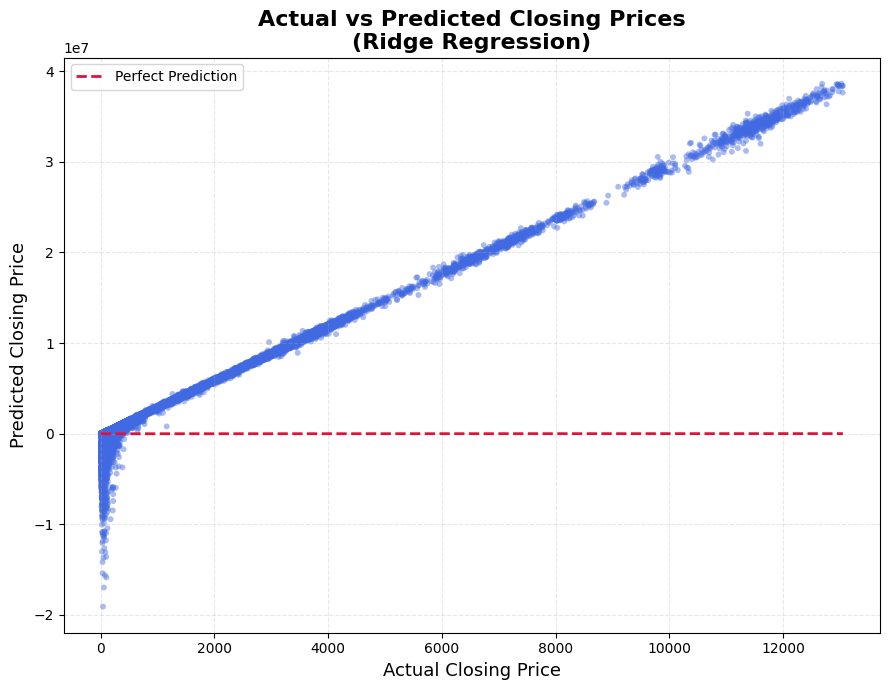

In [72]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9,7))

plt.scatter(
    y_test_reg,
    ridge_pred,
    color="royalblue",
    alpha=0.45,
    s=18,
    edgecolors="none"
)

# Perfect prediction line
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs Predicted Closing Prices\n(Ridge Regression)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual Closing Price", fontsize=13)
plt.ylabel("Predicted Closing Price", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

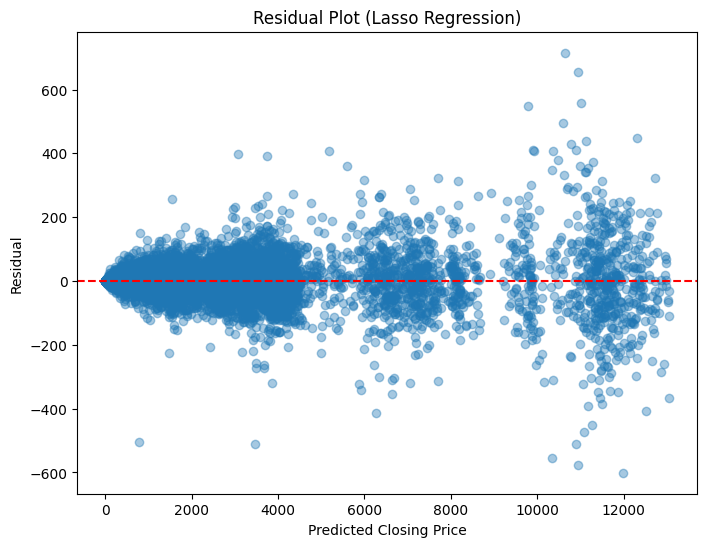

In [61]:
residuals = y_test_reg - lasso_pred
plt.figure(figsize=(8,6))
plt.scatter(
    lasso_pred,
    residuals,
    alpha=0.4)
plt.axhline(
    y=0,
    color="red",
    linestyle="--")
plt.xlabel("Predicted Closing Price")
plt.ylabel("Residual")
plt.title("Residual Plot (Lasso Regression)")
plt.show()

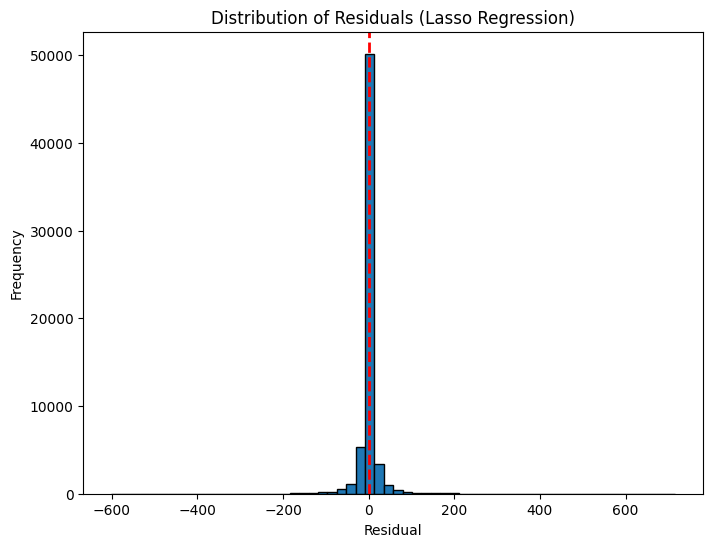

In [62]:
plt.figure(figsize=(8,6))
plt.hist(
    residuals,
    bins=60,
    edgecolor="black")
plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals (Lasso Regression)")
plt.show()

In [63]:
import joblib

joblib.dump(
    lasso,
    r"D:\projects\AI-Stock-Analytics-System\models\trained_models\regression\regression_lasso.pkl"
)

print("Regression model saved successfully.")

Regression model saved successfully.


In [64]:
joblib.dump(
    scaler,
    r"D:\projects\AI-Stock-Analytics-System\models\trained_models\regression\regression_scaler.pkl"
)

print("Regression scaler saved successfully.")

Regression scaler saved successfully.


In [65]:
joblib.dump(
    feature_columns,
    r"D:\projects\AI-Stock-Analytics-System\models\trained_models\regression\regression_features.pkl"
)

print("Feature list saved successfully.")

Feature list saved successfully.


In [66]:
regression_metadata = {
    "model_name": "Lasso Regression",
    "mae": lasso_mae,
    "rmse": lasso_rmse,
    "r2": lasso_r2,
    "target": "Target_Close"}
joblib.dump(
    regression_metadata,
    r"D:\projects\AI-Stock-Analytics-System\models\trained_models\regression\regression_metadata.pkl")
print("Regression metadata saved successfully.")

Regression metadata saved successfully.


Seven regression models were evaluated to predict the next trading day's closing price.

The models were compared using MAE, RMSE, and R² Score.

Ridge Regression achieved the best overall performance while also performing automatic 
feature selection.

Although tree-based models such as Decision Tree, Random Forest, and XGBoost are 
powerful algorithms, 
they did not outperform the linear models because the current day's closing price was 
already a very 
strong predictor of the next day's closing price.

Therefore, Ridge Regression was selected as the final regression model for deployment.

In [67]:
regression_results.to_csv(
    r"D:\projects\AI-Stock-Analytics-System\results\regression_model_comparison.csv",
    index=False
)

print("Regression comparison saved successfully.")

Regression comparison saved successfully.


In [68]:
regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.662020,26.337860,0.999705
1,Linear Regression,9.691324,26.333005,0.999705
2,Ridge Regression,9.690260,26.332608,0.999705
3,Lasso Regression,9.688705,26.334800,0.999705
4,Decision Tree,10.693159,29.739385,0.999624
5,Random Forest,10.017706,27.332978,0.999682
6,XGBoost,19.647845,104.119293,0.995393


In [74]:
print(ridge_pred[:10])

print(y_test_reg[:10])

[4146783.30960032 4267100.36849815 4288269.21242127 4355502.17814197
 4268480.01370365 4304273.88777833 4258526.92557503 4371496.56934423
 4318681.78058666 4355756.79580942]
354849    1487.736450
354850    1474.426392
354851    1489.155396
354852    1470.071289
354853    1486.610840
354854    1478.928345
354855    1496.544434
354856    1483.038818
354857    1489.302246
354858    1462.780151
Name: Target_Close, dtype: float64


In [75]:
print(ridge_pred.min())
print(ridge_pred.max())

-19071831.807040095
38628522.48984018


In [76]:
print(best_ridge.coef_[:10])

[ 3.11588205e+03 -2.50841812e+01 -5.84708548e+01  3.20399414e+01
 -2.98736126e-02 -1.89034536e-02  6.99978077e+01  4.43560204e+02
  6.32948472e+01 -6.03543986e+01]


In [77]:
print(best_ridge.intercept_)

1021.4914518112959


In [78]:
print(best_ridge)

Ridge(alpha=0.01)


In [79]:
print(y_train_reg.describe())

count    354849.000000
mean       1021.491452
std        2945.898326
min           0.413098
25%          82.073647
50%         247.304672
75%         777.437500
max       42240.000000
Name: Target_Close, dtype: float64


In [80]:
print(y_train_reg.head())

0    612.933411
1    615.861389
2    617.158508
3    611.784546
4    607.930115
Name: Target_Close, dtype: float64


In [81]:
ridge_pred = ridge_search.best_estimator_.predict(X_test_reg_scaled)

In [82]:
print(ridge_pred[:5])

[1454.8196902  1487.84699847 1474.731414   1490.66559694 1470.61241899]


In [83]:
ridge_pred = best_ridge.predict(X_test_reg_scaled)

In [84]:
print(ridge_pred.min())
print(ridge_pred.max())

6.8201834031367525
13060.520872091789


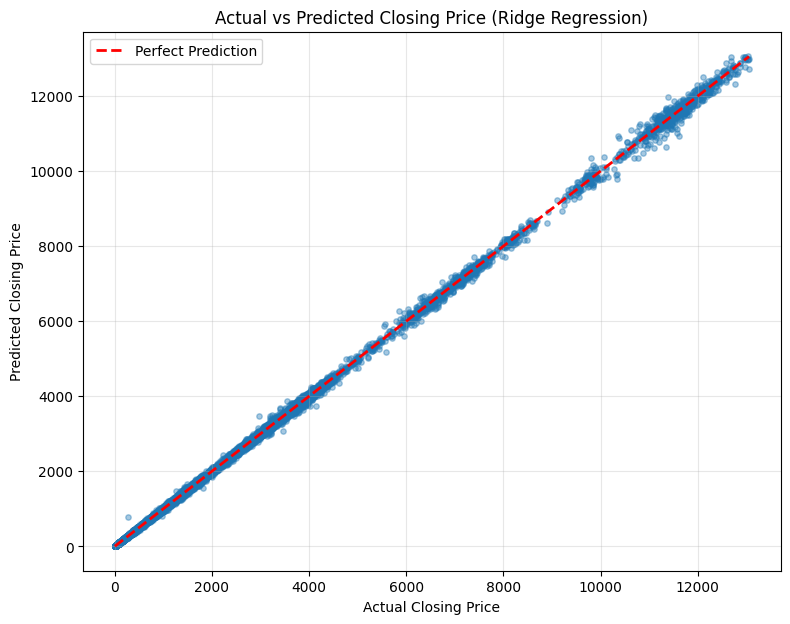

In [85]:
plt.figure(figsize=(9,7))

plt.scatter(
    y_test_reg,
    ridge_pred,
    alpha=0.4,
    s=15
)

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")
plt.title("Actual vs Predicted Closing Price (Ridge Regression)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [86]:
print(best_ridge is ridge_search.best_estimator_)

True


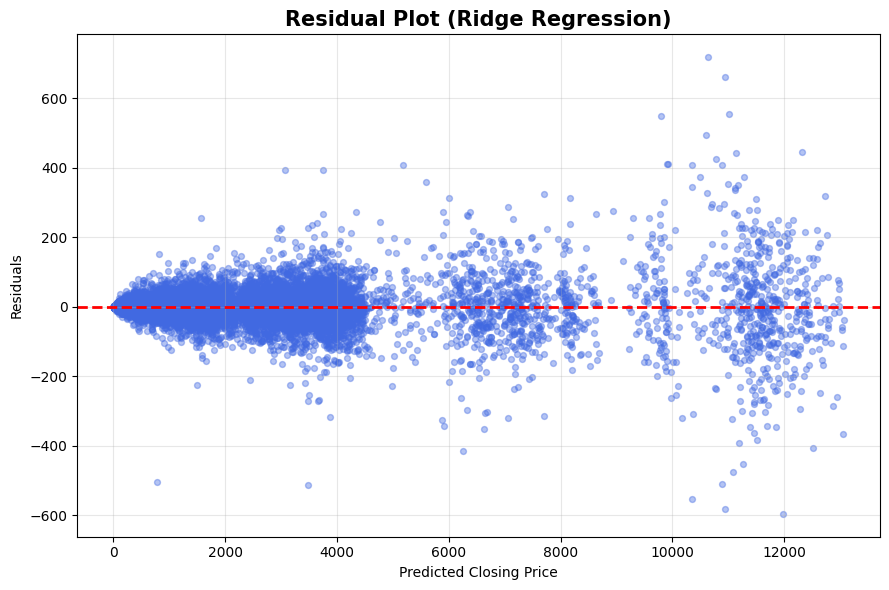

In [87]:
residuals = y_test_reg - ridge_pred

plt.figure(figsize=(9,6))

plt.scatter(
    ridge_pred,
    residuals,
    alpha=0.4,
    s=18,
    color="royalblue"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Residual Plot (Ridge Regression)", fontsize=15, fontweight="bold")
plt.xlabel("Predicted Closing Price")
plt.ylabel("Residuals")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

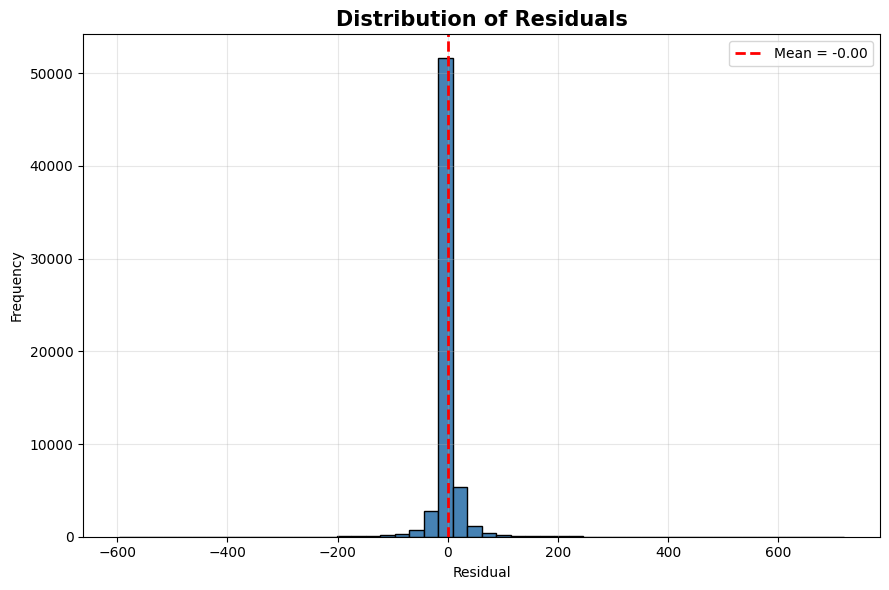

In [88]:
plt.figure(figsize=(9,6))

plt.hist(
    residuals,
    bins=50,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    residuals.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {residuals.mean():.2f}"
)

plt.title("Distribution of Residuals", fontsize=15, fontweight="bold")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [89]:
comparison = pd.DataFrame({
    "Actual Closing Price": y_test_reg.values,
    "Predicted Closing Price": ridge_pred,
    "Residual": residuals
})

comparison.head(20)

,Actual Closing Price,Predicted Closing Price,Residual
354849,1487.736450,1454.819690,32.916760
354850,1474.426392,1487.846998,-13.420607
354851,1489.155396,1474.731414,14.423982
354852,1470.071289,1490.665597,-20.594308
354853,1486.610840,1470.612419,15.998421
354854,1478.928345,1488.001980,-9.073635
354855,1496.544434,1479.640180,16.904253
354856,1483.038818,1498.141626,-15.102808
354857,1489.302246,1483.251481,6.050765
354858,1462.780151,1490.652318,-27.872167


In [90]:
comparison["Absolute Error"] = abs(
    comparison["Actual Closing Price"] -
    comparison["Predicted Closing Price"]
)

comparison["Percentage Error (%)"] = (
    comparison["Absolute Error"] /
    comparison["Actual Closing Price"]
) * 100

comparison.head(20)

,Actual Closing Price,Predicted Closing Price,Residual,Absolute Error,Percentage Error (%)
354849,1487.736450,1454.819690,32.916760,32.916760,2.212540
354850,1474.426392,1487.846998,-13.420607,13.420607,0.910226
354851,1489.155396,1474.731414,14.423982,14.423982,0.968602
354852,1470.071289,1490.665597,-20.594308,20.594308,1.400905
354853,1486.610840,1470.612419,15.998421,15.998421,1.076167
354854,1478.928345,1488.001980,-9.073635,9.073635,0.613528
354855,1496.544434,1479.640180,16.904253,16.904253,1.129552
354856,1483.038818,1498.141626,-15.102808,15.102808,1.018369
354857,1489.302246,1483.251481,6.050765,6.050765,0.406282
354858,1462.780151,1490.652318,-27.872167,27.872167,1.905424


In [91]:
import joblib

joblib.dump(best_ridge, "../models/best_ridge_regression.pkl")

['../models/best_ridge_regression.pkl']

In [92]:
joblib.dump(scaler, "../models/regression_scaler.pkl")

['../models/regression_scaler.pkl']

In [93]:
joblib.dump(feature_columns, "../models/regression_feature_columns.pkl")

['../models/regression_feature_columns.pkl']

In [94]:
regression_metadata = {
    "model_name": "Ridge Regression",
    "target": "Target_Close",
    "features": feature_columns,
    "mae": ridge_mae,
    "rmse": ridge_rmse,
    "r2_score": ridge_r2,
    "best_alpha": ridge_search.best_params_["alpha"]
}

joblib.dump(
    regression_metadata,
    "../models/regression_metadata.pkl"
)

['../models/regression_metadata.pkl']

In [95]:
regression_results


,Model,MAE,RMSE,R2
0,Baseline,9.662020,26.337860,0.999705
1,Linear Regression,9.691324,26.333005,0.999705
2,Ridge Regression,9.690260,26.332608,0.999705
3,Lasso Regression,9.688705,26.334800,0.999705
4,Decision Tree,10.693159,29.739385,0.999624
5,Random Forest,10.017706,27.332978,0.999682
6,XGBoost,19.647845,104.119293,0.995393
